> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy


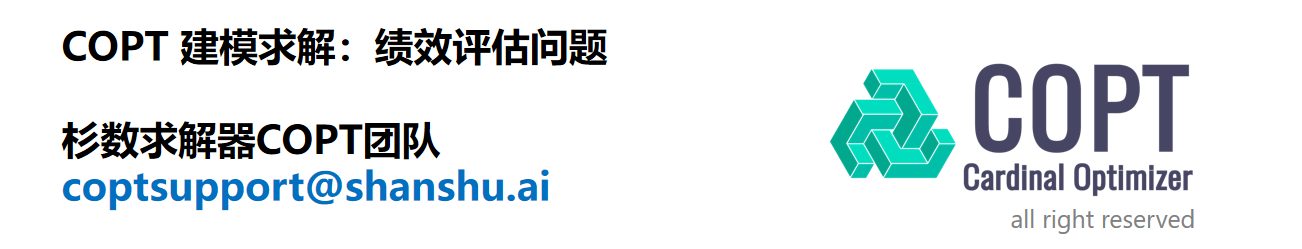

# 绩效评估问题代码实现
## 使用COPT建模求解绩效评估问题的步骤

1. **导入COPT-Python接口库** `coptpy`

2. **导入、预处理数据**
    - 导入所有门店的全年数据
    - 分离输入项与输出项

3. **创建COPT求解环境与模型**

4. **构建模型：依次添加三要素**
    - **决策变量**：
        - $x_{d}$：第 $d$ 家门店在虚拟标杆中所占的**权重**（即“混合比例”，非负）
        - $w$：虚拟标杆的产出相对于目标门店产出的**倍数**（即效率缺口指数）
    - **目标函数**：最大化虚拟标杆的产出倍数 $w$，即寻找对目标门店“威胁最大”的虚拟组合
    - **约束条件**：
        - **投入约束**：确保虚拟组合门店的各项投入指标不高于目标门店的实际投入
        - **产出约束**：要求虚拟组合门店的各项产出指标至少达到目标门店实际产出的 $w$ 倍

5. **求解**

6. 查看、分析**结果**

## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT

## 添加模型数据

In [6]:
# 数据表列标题
data_column_title = ['Total_Cost', 'Staff_Cost', 'Non-staff_Cost', 'Age_of_Store', 'Competition', 'Customer_Service', 'Revenue']
data = [[1310, 238, 1072, 18, 11, 8,  1419],
        [2091, 459, 1632, 46, 12, 8,  3064],
        [930,  154, 776,  36, 9,  5,  987],
        [3591, 795, 2796, 34, 9,  7,  3603],
        [2729, 571, 2158, 35, 13, 9,  2742],
        [2030, 497, 1533, 57, 7,  6,  2536],
        [3247, 558, 2689, 36, 5,  9,  4320],
        [2501, 571, 1930, 40, 12, 7,  3495],
        [2299, 407, 1892, 17, 8,  8,  2461],
        [2413, 306, 2107, 23, 16, 5,  1851],
        [1450, 458, 992,  49, 18, 10, 1935],
        [2758, 494, 2264, 35, 9,  8,  3558],
        [1857, 360, 1497, 59, 25, 5,  2088],
        [3195, 618, 2577, 51, 9,  8,  3963],
        [3505, 759, 2746, 38, 12, 9,  3918],
        [1408, 313, 1095, 24, 9,  8,  1693],
        [1127, 253, 874,  17, 5,  7,  1196],
        [1637, 340, 1297, 21, 13, 7,  1945],
        [2305, 551, 1754, 27, 7,  6,  3207],
        [1781, 303, 1478, 34, 29, 4,  1622],
        [3122, 642, 2480, 26, 5,  10, 2334],
        [2597, 465, 2132, 20, 11, 6,  1387],
        [1817, 335, 1482, 28, 4,  9,  1969],
        [3483, 825, 2658, 53, 11, 6,  3422],
        [1954, 424, 1530, 11, 15, 3,  1189],
        [1120, 159, 961,  4,  5,  6,  810],
        [1408, 248, 1160, 36, 7,  3,  1081],
        [3420, 672, 2748, 44, 7,  9,  3088],
        [2242, 364, 1878, 18, 11, 5,  1796],
        [2643, 490, 2153, 27, 6,  7,  3243]]

# 获得门店数量
num_store = len(data)

# 获得参数数量
num_variables = len(data[0])

# 计算各项指标的平均值，用于后续的归一化处理
# 归一化的目的是消除不同指标间量纲（单位）的影响，使得成本与收入在同一尺度下进行比较
ave = [cp.quicksum(data[j][i] for j in range(num_store)) / num_store for i in range(num_variables)]

for j in range(num_store):
    for i in range(num_variables):
        data[j][i] /= ave[i]  # 将原始数据转换为相对于平均值的倍数

# 确定输入项与输出项
# 输入项为['Total_Cost', 'Staff_Cost', 'Non-staff_Cost', 'Age_of_Store', 'Competition']
# 即前五列
num_input = 5
input = [0, 1, 2, 3, 4]
# 输出项为['Customer_Service', 'Revenue']
# 即后两列
num_output = 2
output = [5, 6]

## 创建求解环境和求解模型

In [8]:
env = cp.Envr()
model = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素
以第0家门店为例

In [10]:
p = 0

### 添加决策变量
1. $x_{d}$：第 $d$ 家门店在虚拟标杆中所占的**权重**（即“混合比例”，非负）

In [12]:
x = model.addVars(num_store, lb=0, nameprefix='x')

2. $w$：虚拟标杆的产出相对于目标门店产出的**倍数**（即效率缺口指数）

In [14]:
w = model.addVar(lb=1, name='w')

### 设置目标函数
最大化虚拟标杆的产出倍数 $w$，即寻找对目标门店“威胁最大”的虚拟组合：
$$
    \max \, w
$$

In [16]:
model.setObjective(w, sense=COPT.MAXIMIZE)

### 添加约束条件
1. **投入约束**：确保虚拟组合门店的各项投入指标不高于目标门店的实际投入。
$$
    \sum_{d} a_{d, i} \cdot x_d \leq a_{p, i}, \quad \forall \, i \in \text{Input}
$$

In [18]:
model.addConstrs((cp.quicksum(data[d][i] * x[d] for d in range(num_store)) <= data[p][i] for i in input), nameprefix='input')

2. **产出约束**：要求虚拟组合门店的各项产出指标至少达到目标门店实际产出的 $w$ 倍。
$$
    \sum_{d} b_{d, j} \cdot x_d \geq w \cdot b_{p, j}, \quad \forall \, j \in \text{Output}
$$


In [20]:
model.addConstrs((cp.quicksum(data[d][j] * x[d] for d in range(num_store)) >= w * data[p][j] for j in output), nameprefix='output')

## 求解

In [22]:
model.solve()

Model fingerprint: cf8a40e8

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing an LP problem

The original problem has:
    7 rows, 31 columns and 212 non-zero elements
The presolved problem has:
    7 rows, 31 columns and 212 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [2e-01,3e+00]
    Range of rhs coefficients:       [5e-01,1e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual             0    1.3192525691e+01            2           0       0.03s
Dual             7    9.9999194907e-01            0           0       0.04s
Postsolving
Dual             7    1.0000000000e+00            0           0   

## 获取结果

以上结果为一家门店的投入产出比，我们需要所有门店的投入产出比

<font color=#B9C78D>
<b>提示：COPT中如何便捷的修改现有约束的上下界与变量对应的系数</b>
</font>   

此处我们运用了以下几种方法：
1. `model.getConstrByName()`：通过约束名称定位某一个约束
2. `constr.ub`：给此变量赋值从而直接改变约束的上界
3. `model.setCoeff()`：直接设置决策变量的系数

In [25]:
input_output_ratio = []

# 取消日志文件显示
model.setParam(COPT.Param.Logging, False)

for p in range(num_store):
    # 核心逻辑：在不改变模型结构的情况下，通过更新约束条件来对下一家门店进行评估
    # 1. 更新投入约束的上界：确保“虚拟标杆”的投入不高于当前目标门店 p
    for i in input:
        model.getConstrByName(f'input({i})').ub = data[p][i]
    
    # 2. 更新产出约束中目标变量 w 的系数：将目标门店 p 的产出水平更新到约束中
    for j in output:
        model.setCoeff(model.getConstrByName(f'output({j})'), w, -data[p][j])

    # 求解
    model.solve()

    # 得到最优函数值，也就是最大的投入产出比
    if model.status == COPT.OPTIMAL:
        # 取倒数得到其效率值
       input_output_ratio.append([p + 1, min(1 / model.objval, 1.0)])
    else:
       print(f'第{p}家门店的最优投入产出比求解失败！')

if len(input_output_ratio) == num_store:
    input_output_ratio.sort(key=lambda x: (-x[1], x[0]))
    for i in range(10):
        print("{:^5} {:^10} {:^5} {:^10} {:^5} {:^10}".format(f'门店{input_output_ratio[i][0]}：', round(input_output_ratio[i][1], 4),
                                                              f'门店{input_output_ratio[i + 10][0]}：', round(input_output_ratio[i + 10][1], 4),
                                                              f'门店{input_output_ratio[i + 20][0]}：', round(input_output_ratio[i + 20][1], 4)))

门店1：     1.0     门店23：    1.0     门店10：   0.8204  
门店2：     1.0     门店26：    1.0     门店13：   0.8106  
门店3：     1.0     门店8：    0.9841   门店5：    0.7999  
门店7：     1.0     门店30：   0.9657   门店29：   0.736   
门店9：     1.0     门店18：   0.9652   门店28：   0.7342  
门店11：    1.0     门店12：   0.9612   门店20：   0.7099  
门店16：    1.0     门店6：    0.9339   门店24：   0.7046  
门店17：    1.0     门店14：   0.9032   门店25：   0.6876  
门店19：    1.0     门店15：   0.856    门店27：   0.599   
门店21：    1.0     门店4：    0.8372   门店22：   0.5271  
